In [1]:
import utils_FaIR_JAX
import run_fair
import FaIR_JAX_new
import matplotlib.pyplot as plt

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

## Calibrate JAX SCM using FaIRv2.0.0 outputs
To calibrate our simple climate model written in JAX (parameters and model structure chosen to reproduce FaIR, e.g., carbon cycle with four reservoirs), we first generate a set of single-forcing scenarios using the baseline FaIR model. We then use our inverse model to iteratively update our initial parameter guesses to reproduce the FaIR temperature response for each agent.

#### 1. CO<sub>2</sub> calibration

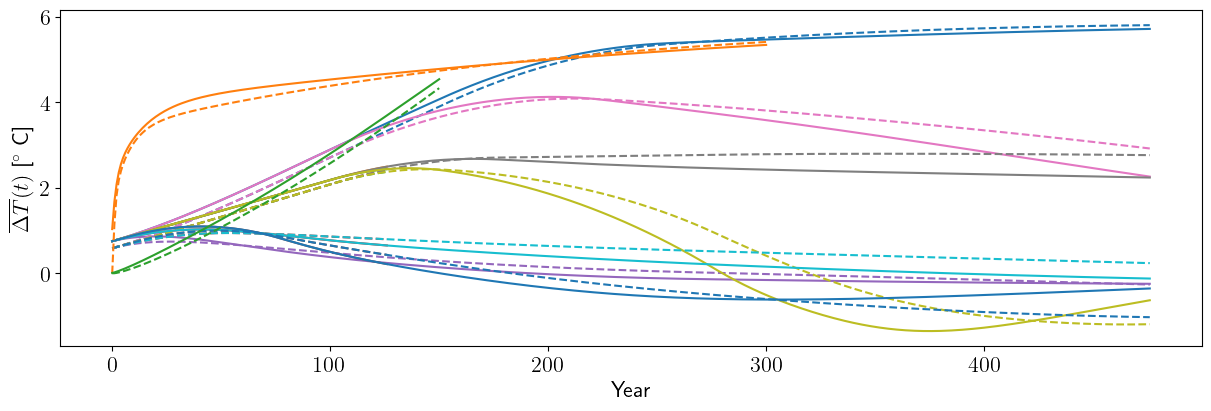

In [126]:
# Generate calibration dataset
agents = ['CO2']
#conc_to_temp, em_to_conc, em_to_temp = FaIR_JAX_new.get_fair_jax()
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = FaIR_JAX_new.generate_calib_data(agents, mode='FaIR')

# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

In [ ]:
filepath = 'data/JAX_calibration/calib_CO2_only_new.pkl'
theta0 = FaIR_JAX_new.make_theta0(mode='FaIR')
learning_rate = 1e-2
n_steps = 10
theta_opt, final_loss = FaIR_JAX_new.calibrate_inverse(filepath, emis_dict_calib_FaIR, delT_dict_calib_FaIR, theta0, learning_rate, n_steps, target='CO2')

agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = FaIR_JAX_new.generate_calib_data(agents, mode='Calibrate', params_in=theta_opt)
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

#### 2. CH<sub>4</sub> calibration

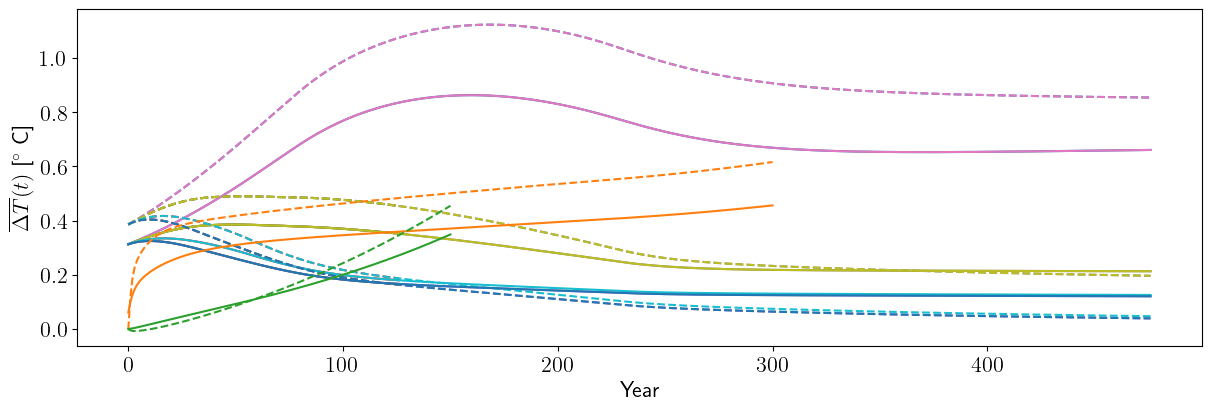

In [37]:
# Generate calibration dataset
agents = ['CH4']
conc_to_temp, em_to_conc, em_to_temp = FaIR_JAX_new.get_fair_jax()
emis_dict_calib_FaIR, delT_dict_calib_FaIR, delT_dict_calib_JAX = FaIR_JAX_new.generate_calib_data(agents, mode='FaIR')

# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

Starting calibration for target: CH4
Step    0 | MSE Loss: 0.01427336
Step   10 | MSE Loss: 0.00297928
Step   20 | MSE Loss: 0.00363752
Step   30 | MSE Loss: 0.00267702
Step   40 | MSE Loss: 0.00278657
Step   49 | MSE Loss: 0.00268357


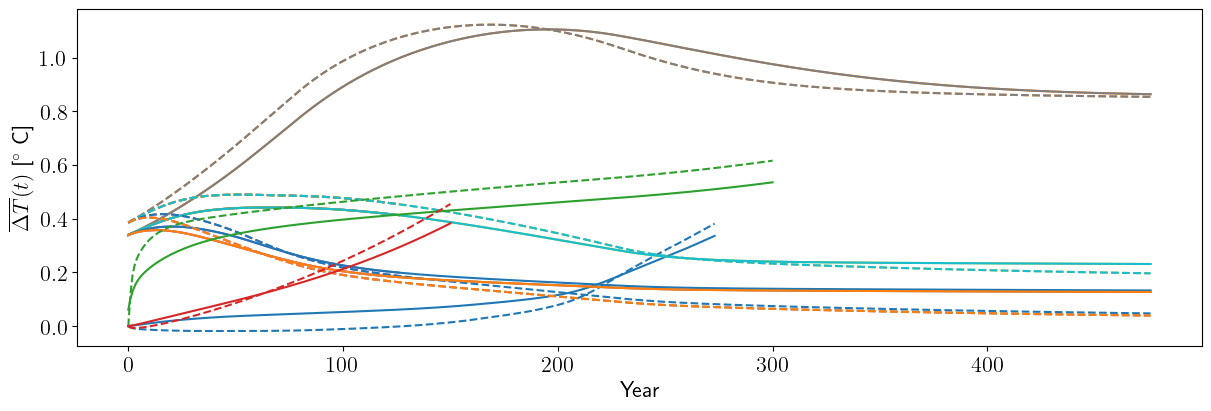

In [98]:
filepath = 'data/JAX_calibration/calib_CH4_only_new.pkl'
theta0 = FaIR_JAX_new.make_theta0(mode='FaIR')
learning_rate = 1e-5
n_steps = 50
theta_opt, final_loss = FaIR_JAX_new.calibrate_inverse(filepath, emis_dict_calib_FaIR, delT_dict_calib_FaIR, theta0, learning_rate, n_steps, target='CH4')

conc_to_temp_calib, em_to_conc_calib, em_to_temp_calib = FaIR_JAX_new.get_fair_jax(mode='Calibrate', params_in=theta_opt)
emis_dict_calib_FaIR, delT_dict_calib_FaIR, delT_dict_calib_JAX = FaIR_JAX_new.generate_calib_data(em_to_temp_calib, agents)
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

#### 3. N<sub>2</sub>O calibration

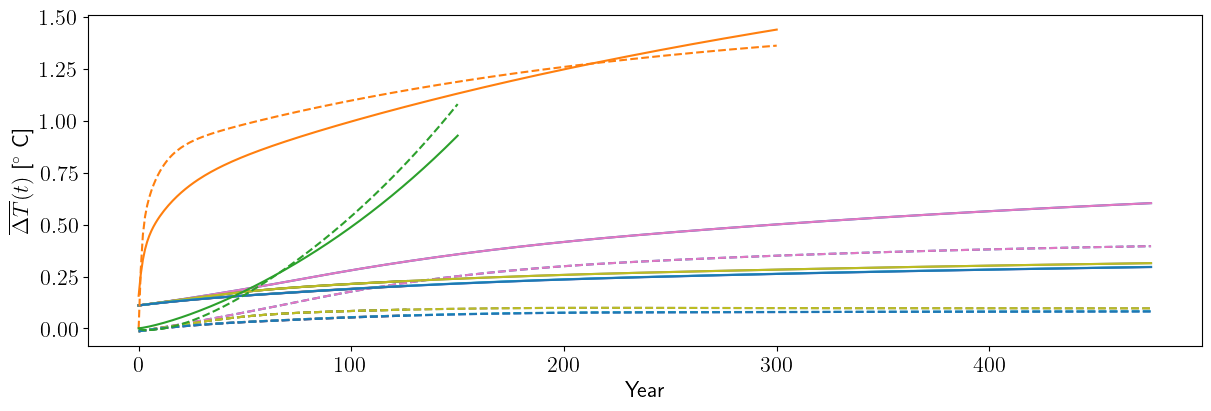

In [39]:
# Generate calibration dataset
agents = ['N2O']
conc_to_temp, em_to_conc, em_to_temp = FaIR_JAX_new.get_fair_jax()
emis_dict_calib_FaIR, delT_dict_calib_FaIR, delT_dict_calib_JAX = FaIR_JAX_new.generate_calib_data(agents, mode='FaIR')

# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

Starting calibration for target: N2O
Step    0 | MSE Loss: 0.02359555
Step   10 | MSE Loss: 0.02290191
Step   20 | MSE Loss: 0.02224853
Step   30 | MSE Loss: 0.02163893
Step   40 | MSE Loss: 0.02107457
Step   49 | MSE Loss: 0.02060512


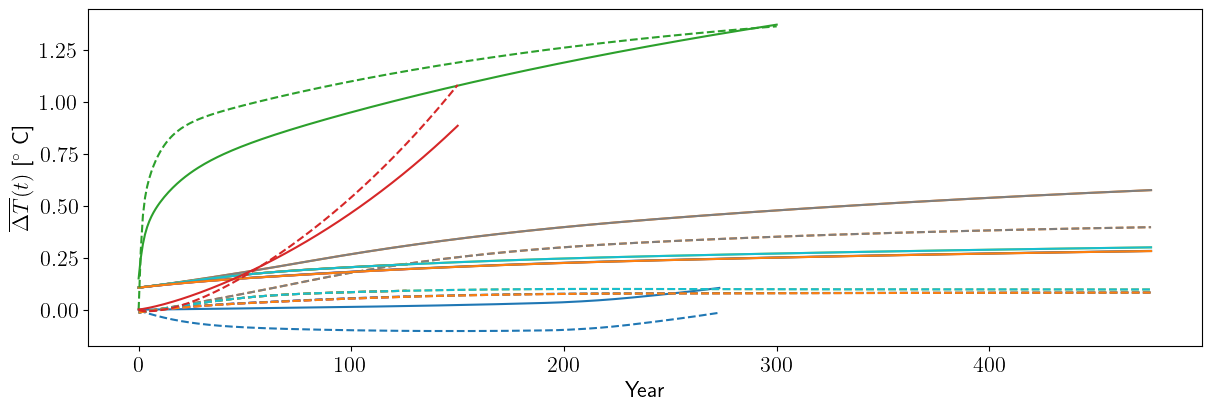

In [108]:
filepath = 'data/JAX_calibration/calib_N2O_only_new.pkl'
theta0 = FaIR_JAX_new.make_theta0(mode='FaIR')
learning_rate = 1e-2
n_steps = 50
theta_opt, final_loss = FaIR_JAX_new.calibrate_inverse(filepath, emis_dict_calib_FaIR, delT_dict_calib_FaIR, theta0, learning_rate, n_steps, target='N2O')

conc_to_temp_calib, em_to_conc_calib, em_to_temp_calib = FaIR_JAX_new.get_fair_jax(mode='Calibrate', params_in=theta_opt)
emis_dict_calib_FaIR, delT_dict_calib_FaIR, delT_dict_calib_JAX = FaIR_JAX_new.generate_calib_data(em_to_temp_calib, agents)
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

#### 4. Sulfur and black carbon calibration
Both have to be completed simultaneously since they depend on the same set of parameters.

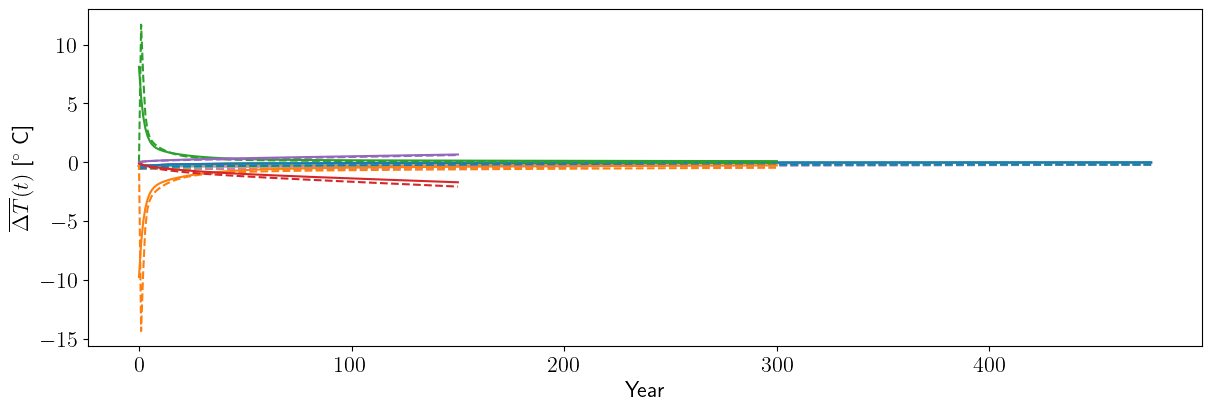

In [45]:
# Generate calibration dataset
agents = ['Sulfur', 'BC']
conc_to_temp, em_to_conc, em_to_temp = FaIR_JAX_new.get_fair_jax()
emis_dict_calib_FaIR, delT_dict_calib_FaIR, delT_dict_calib_JAX = FaIR_JAX_new.generate_calib_data(agents, mode='FaIR')

# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

In [78]:
# Simulation parameters
dt = 0.1
n_steps = 10
filepath = 'data/JAX_calibration/calib_Sulfur_BC.pkl'

# Generate default parameters and then optimize
theta0 = utils_FaIR_JAX.make_theta0(utils_FaIR_JAX.DEFAULT_PARAMS)
theta_opt, loss_value = utils_FaIR_JAX.calibrate_inverse(filepath, emis_dict_calib_JAX, delT_dict_calib_FaIR, theta0, dt, n_steps, target='Aer')

step    0 | loss_avg = 0.11026
Final loss_avg: 0.10237575322389603
